In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv("temiz_veri/birlesik_veri.csv", index_col='datetime', parse_dates=True)

print("Veri boyutu:", df.shape)
print("Tarih aralığı:", df.index.min(), "→", df.index.max())
df.head(3)

Veri boyutu: (34168, 10)
Tarih aralığı: 2006-12-16 17:00:00 → 2010-11-26 21:00:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,temperature_2m,relative_humidity_2m,precipitation
datetime,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,7.4,95,1.0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,6.7,93,0.8
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,6.3,93,0.2


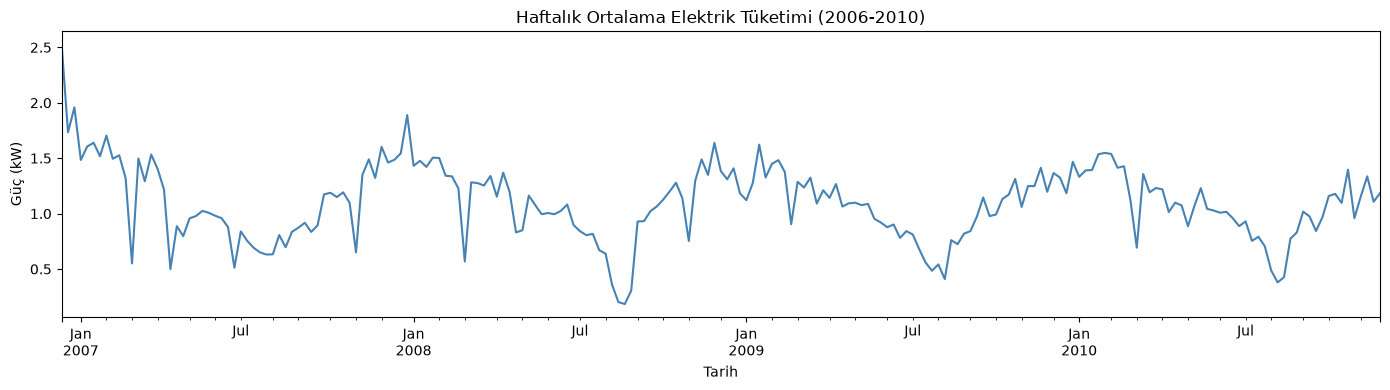

In [2]:
fig, ax = plt.subplots(figsize=(14, 4))
df['Global_active_power'].resample('W').mean().plot(ax=ax, color='steelblue')
ax.set_title('Haftalık Ortalama Elektrik Tüketimi (2006-2010)')
ax.set_ylabel('Güç (kW)')
ax.set_xlabel('Tarih')
plt.tight_layout()
plt.show()

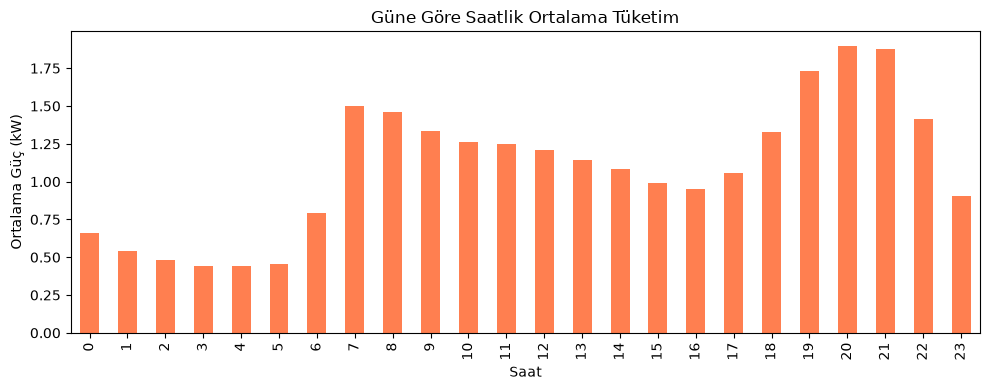

In [3]:
df['saat'] = df.index.hour

saatlik_ort = df.groupby('saat')['Global_active_power'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
saatlik_ort.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Güne Göre Saatlik Ortalama Tüketim')
ax.set_xlabel('Saat')
ax.set_ylabel('Ortalama Güç (kW)')
plt.tight_layout()
plt.show()

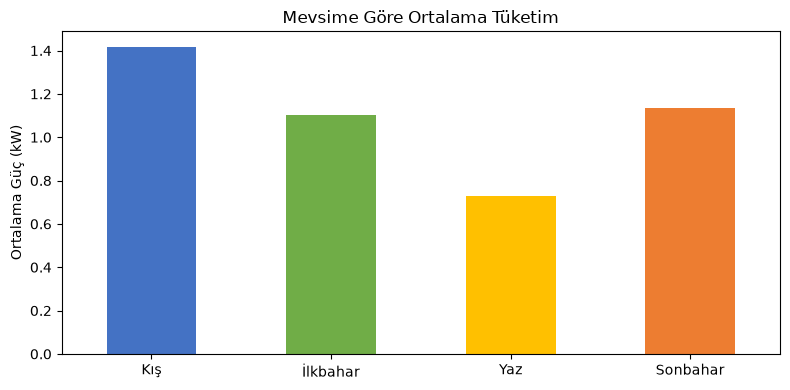

In [4]:
df['mevsim'] = df.index.month.map({
    12:'Kış', 1:'Kış', 2:'Kış',
    3:'İlkbahar', 4:'İlkbahar', 5:'İlkbahar',
    6:'Yaz', 7:'Yaz', 8:'Yaz',
    9:'Sonbahar', 10:'Sonbahar', 11:'Sonbahar'
})

mevsim_ort = df.groupby('mevsim')['Global_active_power'].mean()
mevsim_ort = mevsim_ort.reindex(['Kış', 'İlkbahar', 'Yaz', 'Sonbahar'])

fig, ax = plt.subplots(figsize=(8, 4))
mevsim_ort.plot(kind='bar', ax=ax, color=['#4472C4','#70AD47','#FFC000','#ED7D31'])
ax.set_title('Mevsime Göre Ortalama Tüketim')
ax.set_ylabel('Ortalama Güç (kW)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

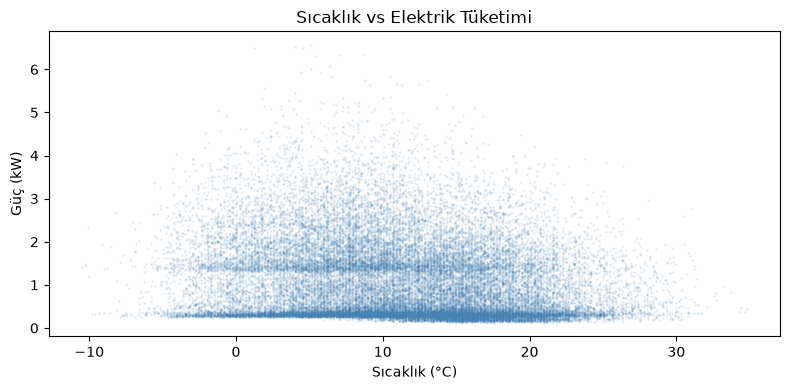

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['temperature_2m'], df['Global_active_power'], 
           alpha=0.1, color='steelblue', s=1)
ax.set_title('Sıcaklık vs Elektrik Tüketimi')
ax.set_xlabel('Sıcaklık (°C)')
ax.set_ylabel('Güç (kW)')
plt.tight_layout()
plt.show()